In [21]:
import os
import random
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torchvision
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader, random_split

from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [23]:
class CarDamageDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None):
        self.data = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_name = self.data.iloc[idx]["filename"]
        label = int(self.data.iloc[idx]["label"])

        img_path = os.path.join(self.img_dir, img_name)
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [24]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

In [25]:
dataset = CarDamageDataset(
    csv_file="clean_labels.csv",
    img_dir="images/",
    transform=transform
)

print("Total dataset:", len(dataset))

Total dataset: 8079


In [26]:
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_data, val_data = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_data, batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False, num_workers=0)

In [27]:
def get_model(model_name):

    if model_name == "alexnet":
        model = torchvision.models.alexnet(pretrained=False)
        model.classifier[6] = nn.Linear(4096, 2)


    else:
        raise ValueError("Invalid model")

    return model

In [28]:
def train_model(model, epochs=5):

    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0003)

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

    return model

In [29]:
def evaluate_model(model):

    model.eval()
    y_true, y_pred, y_prob = [], [], []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)

            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)[:,1]
            preds = torch.argmax(outputs, 1)

            y_true.extend(labels.numpy())
            y_pred.extend(preds.cpu().numpy())
            y_prob.extend(probs.cpu().numpy())

    # Metrics
    acc = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)

    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    auc = roc_auc_score(y_true, y_prob)

    print("\n===== PERFORMANCE =====")
    print("Accuracy:", round(acc,4))
    print("Sensitivity:", round(sensitivity,4))
    print("Specificity:", round(specificity,4))
    print("AUC:", round(auc,4))
    print("\nConfusion Matrix:\n", cm)

    return acc

In [30]:
models_list = ["alexnet",]

results = {}

for name in models_list:
    print(f"\n🔥 Training {name.upper()}")

    model = get_model(name)
    model = train_model(model, epochs=18)

    acc = evaluate_model(model)

    results[name] = acc


🔥 Training ALEXNET


C:\Users\acer\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\acer\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Epoch 1, Loss: 47.0981
Epoch 2, Loss: 42.9814
Epoch 3, Loss: 42.3199
Epoch 4, Loss: 40.4805
Epoch 5, Loss: 41.1472
Epoch 6, Loss: 40.2500
Epoch 7, Loss: 39.6602
Epoch 8, Loss: 38.0904
Epoch 9, Loss: 37.7732
Epoch 10, Loss: 37.3647
Epoch 11, Loss: 37.0425
Epoch 12, Loss: 36.3094
Epoch 13, Loss: 36.3393
Epoch 14, Loss: 36.0813
Epoch 15, Loss: 38.5572
Epoch 16, Loss: 35.3558
Epoch 17, Loss: 34.4945
Epoch 18, Loss: 32.1795

===== PERFORMANCE =====
Accuracy: 0.9474
Sensitivity: 0.0769
Specificity: 0.9993
AUC: 0.8115

Confusion Matrix:
 [[1524    1]
 [  84    7]]


In [31]:
best_model_name = max(results, key=results.get)
print("Best model:", best_model_name)

best_model = get_model(best_model_name)
torch.save(best_model.state_dict(), "best_image_model.pth")

Best model: alexnet


C:\Users\acer\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\acer\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [32]:
classes = ["not_fraud", "fraud"]

def predict_image(img_path, model):

    img = Image.open(img_path).convert("RGB")
    img_tensor = transform(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        output = model(img_tensor)
        pred = torch.argmax(output, 1).item()

    return classes[pred]

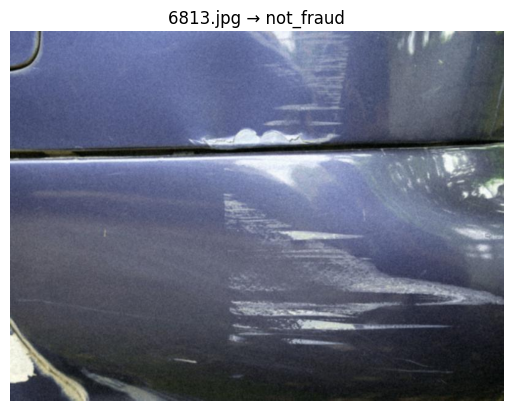

In [37]:
img_list = [img for img in os.listdir("images") if img.endswith(".jpg")]

random_img = random.choice(img_list)
img_path = f"images/{random_img}"

prediction = predict_image(img_path, model)

img = Image.open(img_path)

plt.imshow(img)
plt.title(f"{random_img} → {prediction}")
plt.axis("off")
plt.show()